In [1]:
!pip install -q -U transformers accelerate peft datasets huggingface_hub llmcompressor "numpy<2.1.0"

In [2]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("HF_TOKEN secret not found. Please add it to Colab Secrets.")

Successfully logged in to Hugging Face!


In [3]:
import os
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset, load_from_disk
from llmcompressor.modifiers.awq import AWQModifier
from llmcompressor import oneshot
import wandb

In [ ]:
# ==========================================
# Configuration & Paths
# ==========================================
BASE_MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"
LORA_MODEL_ID = "/content/drive/MyDrive/medical-llama3/llama-3.1-lora-16bit-RESCUED"
QUANTIZED_DIR = "/content/drive/MyDrive/medical-llama3/llama-3.1-awq-4bit"
CACHE_DIR = "./calib_cache"

In [ ]:
def print_vram(step_name):
    """Logs VRAM usage to track memory spikes during the pipeline."""
    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)
    print(f"[{step_name}] VRAM Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB")

In [ ]:
!ls -lh /content/drive/MyDrive/medical-llama3/llama-3.1-lora-16bit-RESCUED

total 15G
-rw------- 1 root root 4.6K Apr 24 21:21 chat_template.jinja
-rw------- 1 root root  969 Apr 24 21:19 config.json
-rw------- 1 root root 4.7G Apr 24 21:20 model-00001-of-00004.safetensors
-rw------- 1 root root 4.7G Apr 24 21:20 model-00002-of-00004.safetensors
-rw------- 1 root root 4.6G Apr 24 21:21 model-00003-of-00004.safetensors
-rw------- 1 root root 1.1G Apr 24 21:21 model-00004-of-00004.safetensors
-rw------- 1 root root  24K Apr 24 21:19 model.safetensors.index.json
-rw------- 1 root root  454 Apr 24 21:21 special_tokens_map.json
-rw------- 1 root root  50K Apr 24 21:21 tokenizer_config.json
-rw------- 1 root root  17M Apr 24 21:21 tokenizer.json


In [ ]:
lora_model = AutoModelForCausalLM.from_pretrained(
    LORA_MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(LORA_MODEL_ID, fix_mistral_regex=True)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
param_size = 0
for param in lora_model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in lora_model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print(f"Model size: {size_all_mb:.3f} MB")


Model size: 15316.508 MB


In [ ]:
# apply the BOS/EOS killswitches just in case
tokenizer.add_bos_token = False
tokenizer.add_eos_token = False

In [ ]:
def format_chat(example):
  messages = [
      {"role": "system", "content": "You are a highly accurate medical AI assistant."},
      {"role": "user", "content": example["input"]},
      {"role": "assistant", "content": example["output"]}
  ]
  full_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False) # the special tag for assistant is added automatically so add_generation_prompt=True will adda second set of special tags

  return {"text": full_prompt}

In [ ]:
# 4. Dataset Prep (34,000 Medical Flashcards)
dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards", split="train")

partial_dataset = dataset.shuffle(seed=3407).select(range(512))

partial_dataset = partial_dataset.map(format_chat, remove_columns=dataset.column_names)

🧠 Loading 16-bit model to CPU (This will take a minute)...
🧮 Scanning 8 Billion Parameters for Global Extrema...
----------------------------------------
📉 Global Minimum Weight: -0.9141
📈 Global Maximum Weight: 0.9102
----------------------------------------
📊 Plotting Distribution for model.layers.16.mlp.down_proj.weight...


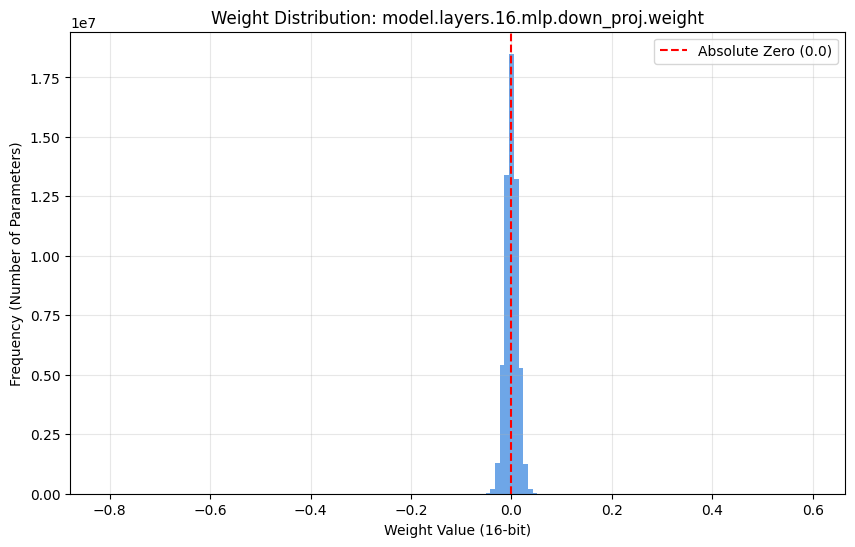

11678

In [ ]:
import matplotlib.pyplot as plt

# Define your merged directory

print("🧠 Loading 16-bit model to CPU (This will take a minute)...")
# Load to CPU so we don't accidentally OOM your GPU before AWQ
model_cpu = lora_model.cpu()

# 1. Calculate Global Min and Max across ALL Linear Weights
print("🧮 Scanning 8 Billion Parameters for Global Extrema...")
global_min = float('inf')
global_max = float('-inf')

for name, param in model_cpu.named_parameters():
    # Only check the layers AWQ will actually quantize (ignore layer norms and lm_head)
    if "weight" in name and "norm" not in name and "lm_head" not in name:
        current_min = param.min().item()
        current_max = param.max().item()

        if current_min < global_min: global_min = current_min
        if current_max > global_max: global_max = current_max

print("-" * 40)
print(f"📉 Global Minimum Weight: {global_min:.4f}")
print(f"📈 Global Maximum Weight: {global_max:.4f}")
print("-" * 40)

# 2. Extract a Representative Layer for the Histogram
# The down_proj in the middle of the model is usually the largest, most dense weight matrix.
sample_layer_name = "model.layers.16.mlp.down_proj.weight"
print(f"📊 Plotting Distribution for {sample_layer_name}...")

# Detach, convert to standard float32, and flatten to a 1D array
weights_1d = model_cpu.get_parameter(sample_layer_name).detach().float().numpy().flatten()

# 3. Plot the Bell Curve
plt.figure(figsize=(10, 6))
plt.hist(weights_1d, bins=150, color='#4A90E2', alpha=0.8)
plt.title(f"Weight Distribution: {sample_layer_name}")
plt.xlabel("Weight Value (16-bit)")
plt.ylabel("Frequency (Number of Parameters)")

# Draw a red dashed line exactly at 0.0 to check for Symmetry
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Absolute Zero (0.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Clean up the massive CPU RAM footprint before moving to AWQ
del model_cpu
del weights_1d
gc.collect()

In [ ]:
wandb.login(key=userdata.get('WANDB_API_KEY'))
os.environ["WANDB_LOG_MODEL"] = "true"
wandb.init(
    project="medical-llama-3.1-8b-instruct-lora-bf16",
    name="awq-w4a16-calibration",
    job_type="quantization",
    notes="Tracking VRAM spikes during AWQ W4A16 symmetric compression.",
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akhilgalla (foobar41) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
print("\nPreparing for LLM Compressor...")

recipe = [
    AWQModifier(
        ignore=["lm_head"],
        scheme="W4A16",
        targets=["Linear"],
        offload_device=torch.device("cpu")
    )
]

print_vram("Pre-Quantization")
print("Starting LLM Compressor AWQ... (Do not interrupt)")

oneshot(
    model=lora_model,
    dataset=partial_dataset,
    tokenizer=tokenizer,
    recipe=recipe,
    output_dir=QUANTIZED_DIR,
    max_seq_length=2048,
    num_calibration_samples=512
)

print_vram("Post-Quantization")
print("Quantization complete.")


Preparing for LLM Compressor...
[Pre-Quantization] VRAM Allocated: 14.96 GB | Reserved: 14.96 GB
Starting LLM Compressor AWQ... (Do not interrupt)
2026-04-24T22:16:11.007689+0000 | __init__ | WARNING - Disabling tokenizer parallelism due to threading conflict between FastTokenizer and Datasets. Set TOKENIZERS_PARALLELISM=false to suppress this warning.


Tokenizing:   0%|          | 0/512 [00:00<?, ? examples/s]

2026-04-24T22:16:11.998950+0000 | reset | INFO - Compression lifecycle reset
2026-04-24T22:16:12.002218+0000 | from_modifiers | INFO - Creating recipe from modifiers
2026-04-24T22:16:12.073807+0000 | on_initialize | INFO - No AWQModifier.mappings provided, inferring from model...
2026-04-24T22:16:12.084450+0000 | _set_resolved_mappings | WARNING - skipping AWQ for model.layers.0.self_attn.v_proj for mapping AWQMapping(smooth_layer='re:.*v_proj$', balance_layers=['re:.*o_proj$'], activation_hook_target=None) because found incompatible balance layers
2026-04-24T22:16:12.085874+0000 | _set_resolved_mappings | WARNING - skipping AWQ for model.layers.1.self_attn.v_proj for mapping AWQMapping(smooth_layer='re:.*v_proj$', balance_layers=['re:.*o_proj$'], activation_hook_target=None) because found incompatible balance layers
2026-04-24T22:16:12.087193+0000 | _set_resolved_mappings | WARNING - skipping AWQ for model.layers.2.self_attn.v_proj for mapping AWQMapping(smooth_layer='re:.*v_proj$', b

W0424 22:16:12.180000 20575 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
Smoothing:  33%|███▎      | 1/3 [01:17<02:34, 77.18s/it]
Grid search for model.layers.0.post_attention_layernorm:   0%|          | 0/20 [00:00<?, ?it/s]
Grid search for model.layers.0.post_attention_layernorm:   0%|          | 0/20 [00:03<?, ?it/s, best_error=1.982e-06]
Grid search for model.layers.0.post_attention_layernorm:   5%|▌         | 1/20 [00:03<01:02,  3.30s/it, best_error=1.982e-06]
Grid search for model.layers.0.post_attention_layernorm:   5%|▌         | 1/20 [00:06<01:02,  3.30s/it, best_error=1.982e-06]
Grid search for model.layers.0.post_attention_layernorm:  10%|█         | 2/20 [00:06<00:59,  3.30s/it, best_error=1.982e-06]
Grid search for model.layers.0.post_attention_layernorm:  10%|█ 

2026-04-25T01:14:58.484648+0000 | finalize | INFO - Compression lifecycle finalized for 1 modifiers
2026-04-25T01:14:58.485983+0000 | get_model_compressor | INFO - skip_sparsity_compression_stats set to True. Skipping sparsity compression statistic calculations. No sparsity compressor will be applied.



Compressing model: 224it [00:41,  5.43it/s]
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3970: UserWarning: Attempting to save a model with offloaded modules. Ensure that unallocated cpu memory exceeds the `shard_size` (5GB default)
  warnings.warn(


Saving checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[Post-Quantization] VRAM Allocated: 5.32 GB | Reserved: 32.68 GB
Quantization complete.


## Loading the model and testing

In [4]:
print("Loading quantized saved model")
MODEL_ID = "/content/drive/MyDrive/medical-llama3/llama-3.1-awq-4bit"
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, fix_mistral_regex=True)

Loading quantized saved model


Compressing model: 224it [00:00, 1755.72it/s]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print(f"Model size: {size_all_mb:.3f} MB")


Model size: 5436.511 MB


### Testing if tokenizer works

In [ ]:
text = "<|start_header_id|>system<|end_header_id|>"
tokens = tokenizer.encode(text, add_special_tokens=False)
print(tokens)
print([tokenizer.decode([t]) for t in tokens])

[128006, 9125, 128007]
['<|start_header_id|>', 'system', '<|end_header_id|>']


### Checking logits

In [5]:
def tokenize_prompt(prompt):
  message = [
      {"role": "system", "content": "You are a highly accurate medical AI assistant."},
      {"role": "user", "content": prompt}
  ]
  inputs = tokenizer.apply_chat_template(
      message,
      tokenize=True,
      add_generation_prompt=True,
      return_tensors="pt",
      return_dict=True
    ).to("cuda")
  return inputs

In [6]:
prompt = "My head is hurting and my throat is hurting. I also feel weak."
inputs = tokenize_prompt(prompt)

In [7]:
def get_logits(inputs):
  with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        output_scores=True,
        return_dict_in_generate=True,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
  return outputs

In [ ]:
outputs = get_logits(inputs)
outputs.keys()

odict_keys(['sequences', 'scores', 'past_key_values'])

In [ ]:
outputs.sequences, outputs.sequences.shape

(tensor([[128000, 128006,   9125, 128007,    271,  38766,   1303,  33025,   2696,
              25,   6790,    220,     17,     15,     17,     18,    198,  15724,
            2696,     25,    220,     17,     21,  10263,    220,     17,     15,
              17,     19,    271,   2675,    527,    264,   7701,  13687,   6593,
           15592,  18328,     13, 128009, 128006,    882, 128007,    271,     40,
             617,    264,  34653, 128009, 128006,  78191, 128007,    271,     32,
           34653,    374,    264,   4279,  49648,    315,   1690,   2204,   6593,
            4787,     13,   1102,    374,   4613,    439,    264,   2547,   9499,
            3485,    220,   1041,     13,     19,  59572,    320,   1987,  32037,
             570,    578,   4839,   5353,    315,    264,  34653,    374,    539,
            7373,  16365,     11,    719,    433,    374,   3463,    311,    387,
             264,   2077,    311,    279,   9546,    315,   3738,  33155,     11,
            1778

In [ ]:
outputs.scores, len(outputs.scores), outputs.scores[0].shape

((tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[141.2500,     -inf,     -inf,  ...,     -inf,     -inf,     -inf]],
         device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], device='cuda:0'),
  tensor([[129.3750,     -inf,     -inf,  ...,     -inf,     -inf,     -inf]],
         device='cuda:0'),
  tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]], dev

In [ ]:
outputs.past_key_values

DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer])

In [ ]:
print("\n--- 🧠 Logit Math for Token 1 ---")
# outputs.scores[0] contains the raw un-normalized scores for the very first generated token
first_token_logits = outputs.scores[0][0]

# Extract the top 5 highest probabilities
top_scores = torch.topk(first_token_logits, 5)

for i in range(5):
    token_id = top_scores.indices[i].item()
    score = top_scores.values[i].item()
    decoded_word = tokenizer.decode([token_id])

    # Clean up whitespace/newlines for cleaner printing
    display_word = repr(decoded_word)
    print(f"Rank {i+1}: {display_word.ljust(15)} | Score: {score:.4f} | ID: {token_id}")

print("\n--- 📝 Actual Generated Output ---")
prompt_length = inputs['input_ids'].shape[1]
print(tokenizer.decode(outputs.sequences[0][prompt_length:], skip_special_tokens=False))


--- 🧠 Logit Math for Token 1 ---
Rank 1: 'A'             | Score: 192.5000 | ID: 32
Rank 2: 'I'             | Score: 187.5000 | ID: 40
Rank 3: 'The'           | Score: 182.5000 | ID: 791
Rank 4: 'If'            | Score: 181.2500 | ID: 2746
Rank 5: 'What'          | Score: 180.0000 | ID: 3923

--- 📝 Actual Generated Output ---
A fever is a common symptom of many different medical conditions. It is defined as a body temperature above 100.4°F (38°C). The exact cause of a fever is not fully understood, but it is thought to be a response to the presence of certain substances, such as cytokines, in the body. These substances are released in response to an infection or other inflammatory process, and they stimulate the hypothalamus, the part of the brain that regulates body temperature, to raise the body


### checking logits with input from dataset

In [ ]:
prompt = "What are some possible causes of low PTH and high calcium levels?"
inputs = tokenize_prompt(prompt)

In [ ]:
outputs = get_logits(inputs)

In [ ]:
print("\n--- 🧠 Logit Math for Token 1 ---")
# outputs.scores[0] contains the raw un-normalized scores for the very first generated token
first_token_logits = outputs.scores[0][0]

# Extract the top 5 highest probabilities
top_scores = torch.topk(first_token_logits, 5)

for i in range(5):
    token_id = top_scores.indices[i].item()
    score = top_scores.values[i].item()
    decoded_word = tokenizer.decode([token_id])

    # Clean up whitespace/newlines for cleaner printing
    display_word = repr(decoded_word)
    print(f"Rank {i+1}: {display_word.ljust(15)} | Score: {score:.4f} | ID: {token_id}")

print("\n--- 📝 Actual Generated Output ---")
print(tokenizer.decode(outputs.sequences[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False))


--- 🧠 Logit Math for Token 1 ---
Rank 1: 'Low'           | Score: 216.2500 | ID: 25162
Rank 2: 'Some'          | Score: 185.0000 | ID: 8538
Rank 3: 'There'         | Score: 185.0000 | ID: 3947
Rank 4: 'Ca'            | Score: 178.7500 | ID: 23389
Rank 5: 'The'           | Score: 176.2500 | ID: 791

--- 📝 Actual Generated Output ---
Low PTH and high calcium levels can be caused by a variety of factors, including hyperparathyroidism, vitamin D toxicity, and familial hypocalcemic hypercalcemia. Hyperparathyroidism is a condition in which the parathyroid glands produce too much PTH, leading to high levels of calcium in the blood. Vitamin D toxicity can also cause high calcium levels, as vitamin D helps the body absorb calcium from the diet. Familial hypocalcemic hypercalcemia is


### Testing and refining system prompt

In [14]:
def tokenize_prompt(prompt, context=None):
  question=prompt
  messages = [
            {
                "role": "system",
                "content": (
                    "You are an expert, empathetic clinical diagnostic AI trained on USMLE standards. "
                    "You must seamlessly route the user's input into one of THREE internal protocols without ever announcing your structural steps or sounding robotic:\n\n"
                    "1. PURE QUESTION (No personal symptoms): Provide a direct, authoritative answer using the provided context.\n"
                    "2. PURE SYMPTOMS (No specific question): Adopt the persona of a warm clinical intake physician. Validate their discomfort using natural conversational empathy (e.g., 'I am sorry you are feeling so unwell'), but ABSOLUTELY DO NOT repeat or echo their exact prompt back to them. Weave 2 to 3 specific differential diagnoses from the context into your response. Conclude by asking a single targeted follow-up question to narrow the scope.\n"
                    "3. MIXED (Symptoms stated AND a specific question asked): You MUST format your response EXACTLY like this template:\n"
                    "   [Write a brief empathetic paragraph validating their discomfort (without repeating their prompt), and weaving in 2 to 3 differential diagnoses]\n\n"
                    "   [Write a Markdown bulleted list directly answering their question]\n"
                    "   (CRITICAL: Stop generating immediately after the list. No concluding paragraph. No follow-up questions.)\n\n"
                    "CRITICAL: Never use formulaic phrases like 'Protocol 3' or 'Here is a list'. Speak conversationally."
                    f"\n\nContext:\n{context}"
                )
            },
            {
                "role": "user",
                "content": question
            }
        ]
  inputs = tokenizer.apply_chat_template(
      messages,
      tokenize=True,
      add_generation_prompt=True,
      return_tensors="pt",
      return_dict=True
    ).to("cuda")
  return inputs

In [21]:
prompt = "How do I feel better and prevent a flu?"
inputs = tokenize_prompt(prompt)

In [22]:
def get_logits(inputs):
  with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=2048,
        output_scores=True,
        return_dict_in_generate=True,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
  return outputs

In [23]:
outputs = get_logits(inputs)
prompt_length = inputs['input_ids'].shape[1]
print(tokenizer.decode(outputs.sequences[0][prompt_length:], skip_special_tokens=False))

I am sorry you are feeling so unwell. The flu is a viral infection that can cause fever, cough, sore throat, and body aches. To feel better and prevent the flu, it is important to get plenty of rest and stay hydrated by drinking plenty of fluids. Over-the-counter medications such as acetaminophen or ibuprofen can help relieve symptoms such as fever and body aches. It is also important to practice good hygiene, such as washing your hands frequently and avoiding close contact with others who may be sick. What are your symptoms like today?<|eot_id|>


### checking logits with prompt the same as training script (newline character) - Only for llama-3

In [ ]:
llama3_prompt = """<|start_header_id|>system<|end_header_id|>
You are a highly accurate medical AI assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>
{}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

input_text = "My eyes hurt and are red"

prompt = llama3_prompt.format(input_text)

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [ ]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        output_scores=True,
        return_dict_in_generate=True,
        temperature=0.1,
        do_sample=True
    )

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
print("\n--- 🧠 Logit Math for Token 1 ---")
# outputs.scores[0] contains the raw un-normalized scores for the very first generated token
first_token_logits = outputs.scores[0][0]

# Extract the top 5 highest probabilities
top_scores = torch.topk(first_token_logits, 5)

for i in range(5):
    token_id = top_scores.indices[i].item()
    score = top_scores.values[i].item()
    decoded_word = tokenizer.decode([token_id])

    # Clean up whitespace/newlines for cleaner printing
    display_word = repr(decoded_word)
    print(f"Rank {i+1}: {display_word.ljust(15)} | Score: {score:.4f} | ID: {token_id}")

print("\n--- 📝 Actual Generated Output ---")
print(tokenizer.decode(outputs.sequences[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False))


--- 🧠 Logit Math for Token 1 ---
Rank 1: 'My'            | Score: 133.5938 | ID: 5159
Rank 2: 'What'          | Score: 131.6406 | ID: 3923
Rank 3: '#'             | Score: -inf | ID: 2
Rank 4: '"'             | Score: -inf | ID: 1
Rank 5: '!'             | Score: -inf | ID: 0

--- 📝 Actual Generated Output ---
My eyes hurt and are red.<|end_of_text|>


### same as above with a question from dataset - Only from llama-3

In [ ]:
input_text = "What are some possible causes of low PTH and high calcium levels?"

prompt = llama3_prompt.format(input_text)

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [ ]:
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        output_scores=True,
        return_dict_in_generate=True,
        temperature=0.1,
        do_sample=True
    )

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
print("\n--- 🧠 Logit Math for Token 1 ---")
# outputs.scores[0] contains the raw un-normalized scores for the very first generated token
first_token_logits = outputs.scores[0][0]

# Extract the top 5 highest probabilities
top_scores = torch.topk(first_token_logits, 5)

for i in range(5):
    token_id = top_scores.indices[i].item()
    score = top_scores.values[i].item()
    decoded_word = tokenizer.decode([token_id])

    # Clean up whitespace/newlines for cleaner printing
    display_word = repr(decoded_word)
    print(f"Rank {i+1}: {display_word.ljust(15)} | Score: {score:.4f} | ID: {token_id}")

print("\n--- 📝 Actual Generated Output ---")
print(tokenizer.decode(outputs.sequences[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False))


--- 🧠 Logit Math for Token 1 ---
Rank 1: 'What'          | Score: 159.1406 | ID: 3923
Rank 2: '#'             | Score: -inf | ID: 2
Rank 3: '!'             | Score: -inf | ID: 0
Rank 4: '$'             | Score: -inf | ID: 3
Rank 5: '"'             | Score: -inf | ID: 1

--- 📝 Actual Generated Output ---
What are some possible causes of low PTH and high calcium levels?<|end_of_text|>
